# Lab: Regularization - Ridge and Lasso
## Machine Learning for Managers

### Learning Objectives
By the end of this lab, you will understand:
1. **Why regularization matters** - preventing overfitting in business applications
2. **Ridge Regression** - shrinking coefficients while keeping all variables
3. **Lasso Regression** - automatic feature selection through coefficient elimination
4. **When to use which method** - practical decision-making for real-world problems

---

### The Business Problem: Overfitting

Imagine you're building a model to predict:
- Customer churn
- Product failure rates
- Sales forecasts

**The Challenge:** Your model might fit your historical data *too well* - memorizing noise instead of learning true patterns. This is called **overfitting**.

**The Solution:** Regularization adds a "penalty" for model complexity, forcing simpler, more generalizable models.

---

## Setup

In [19]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, RidgeCV, Lasso, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(1818)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## K Fold Cross-Validation


In [20]:
from sklearn.model_selection import cross_val_score, cross_validate, KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, make_scorer

# Load data
mpg = sns.load_dataset('mpg')
mpg_clean = mpg.dropna()

X = mpg_clean[['cylinders', 'displacement', 'horsepower', 
               'weight', 'acceleration', 'model_year']]
y = mpg_clean['mpg']

mpg.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [21]:
model = LinearRegression()

# Returns negative MSE by default (sklearn convention)
cv_scores = cross_val_score(model, X, y, cv=10, scoring='neg_mean_squared_error')

# Convert to RMSE
cv_rmse = np.sqrt(-cv_scores)

print(f"RMSE for each fold: {cv_rmse}")
print(f"\nMean RMSE: {cv_rmse.mean():.3f} ± {cv_rmse.std():.3f}")


RMSE for each fold: [3.09658886 3.23055146 3.49874884 2.90919512 2.3942171  2.46894075
 4.24156144 3.42923122 5.94740964 4.02428178]

Mean RMSE: 3.524 ± 0.984


In [22]:
# Using cross_validate() - Multiple Metrics"
scoring = {
    'rmse': make_scorer(lambda y, y_pred: np.sqrt(mean_squared_error(y, y_pred)), greater_is_better=False),
    'r2': 'r2'
}

cv_results = cross_validate(model, X, y, cv=10, scoring=scoring, return_train_score=True)

# Calculate metrics
test_rmse = -cv_results['test_rmse']
train_rmse = -cv_results['train_rmse']
test_r2 = cv_results['test_r2']
train_r2 = cv_results['train_r2']

print(f"Test RMSE:  {test_rmse.mean():.3f} ± {test_rmse.std():.3f}")
print(f"Train RMSE: {train_rmse.mean():.3f} ± {train_rmse.std():.3f}")
print(f"Test R²:    {test_r2.mean():.4f} ± {test_r2.std():.4f}")
print(f"Train R²:   {train_r2.mean():.4f} ± {train_r2.std():.4f}")


Test RMSE:  3.524 ± 0.984
Train RMSE: 3.390 ± 0.128
Test R²:    0.6187 ± 0.2401
Train R²:   0.8098 ± 0.0065


## Load and Prepare Data

We'll use two datasets:
1. **Ames Housing Dataset** - Predicting home sale prices with 80+ features
2. **Semiconductor Dataset** - Predicting manufacturing failures with 590+ features

### Why Ames Housing?
- **80+ features** about houses (size, quality, location, amenities, condition, etc.)
- Perfect for demonstrating regularization with many variables
- Very intuitive - everyone understands real estate
- Great business question: **"Which features actually drive home values?"**

In [23]:
from sklearn.datasets import fetch_openml

print("Loading Ames Housing dataset...")
housing_data = fetch_openml(name="house_prices", as_frame=True, parser='auto')
housing_df = housing_data.frame

print(f"Dataset loaded! Shape: {housing_df.shape}")
print(f"\nTarget variable: SalePrice (home sale price)")
print(f"Number of features: {housing_df.shape[1] - 1}")

# Quick peek at the data
housing_df.head()

Loading Ames Housing dataset...
Dataset loaded! Shape: (1460, 81)

Target variable: SalePrice (home sale price)
Number of features: 80


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [24]:
# Check data types and missing values
print("Data Overview:")
print(f"Total features: {housing_df.shape[1]}")
print(f"\nNumeric features: {housing_df.select_dtypes(include=[np.number]).shape[1]}")
print(f"Categorical features: {housing_df.select_dtypes(include=['object', 'category']).shape[1]}")
print(f"\nMissing values: {housing_df.isnull().sum().sum()} total")

Data Overview:
Total features: 81

Numeric features: 38
Categorical features: 43

Missing values: 6965 total


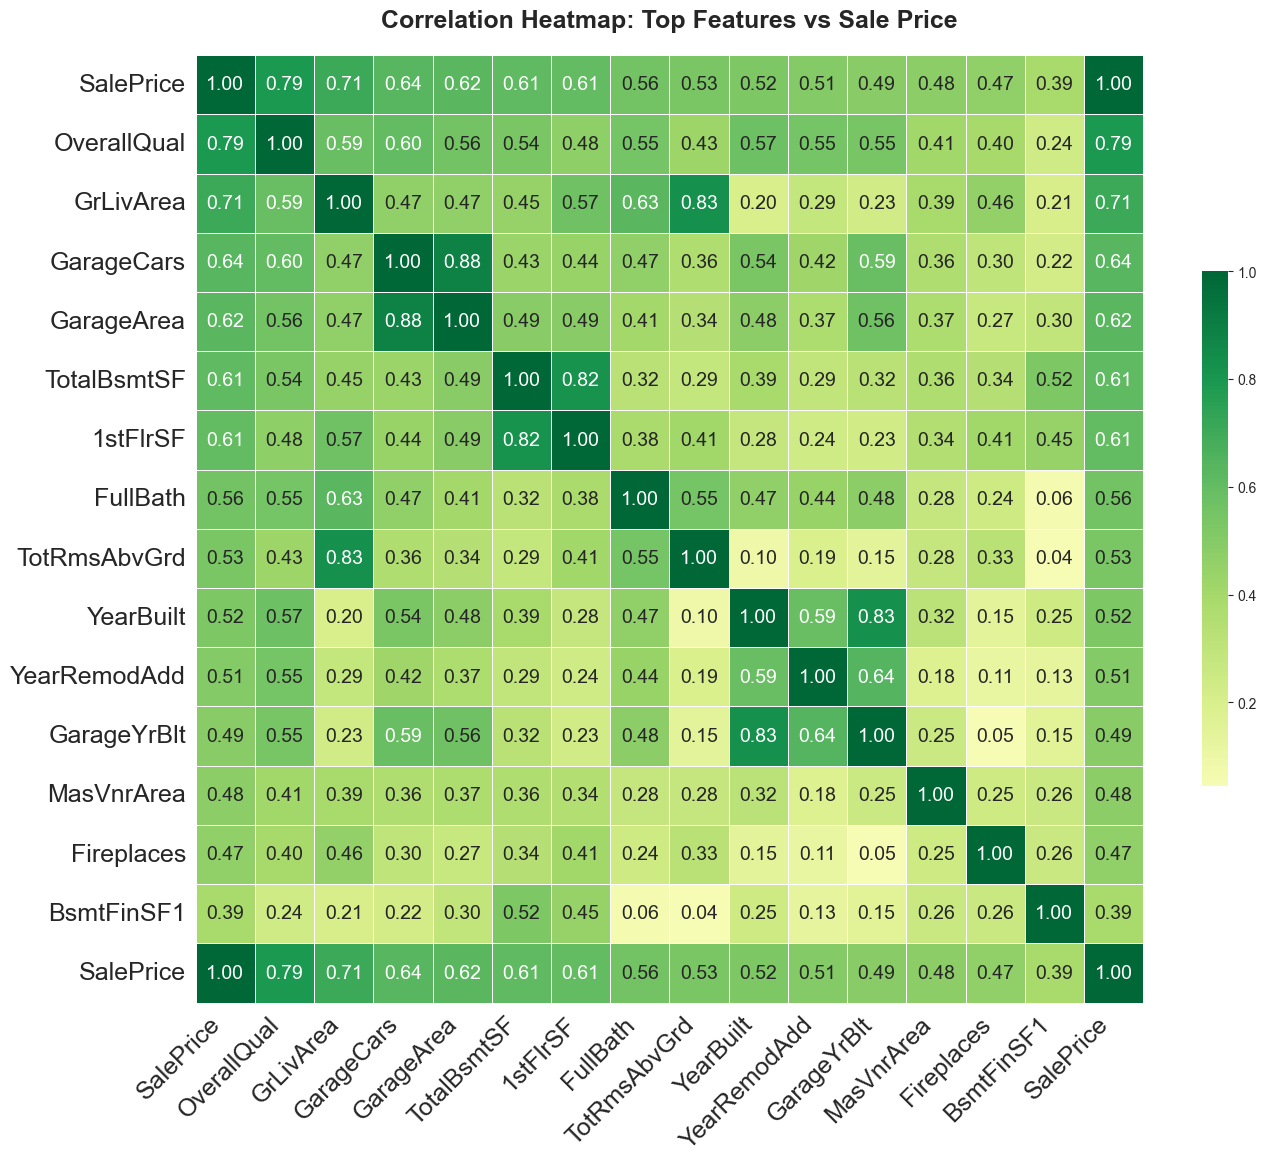

In [25]:
# Quick corr plot
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_cols = housing_df.select_dtypes(include=[np.number]).columns
housing_numeric = housing_df[numeric_cols]

# Calculate correlation with SalePrice
correlations = housing_numeric.corr()['SalePrice'].sort_values(ascending=False)

top_features = correlations.head(15).index.tolist() + ['SalePrice']
corr_matrix = housing_numeric[top_features].corr()

plt.figure(figsize=(14, 12))  # More balanced dimensions
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='RdYlGn', 
            center=0,
            square=True, 
            linewidths=0.5, 
            cbar_kws={"shrink": 0.5},  # Shrink colorbar to 50%
            annot_kws={'fontsize': 14})

plt.title('Correlation Heatmap: Top Features vs Sale Price', 
          fontsize=18, fontweight='bold', pad=20)

plt.xticks(fontsize=18, rotation=45, ha='right')
plt.yticks(fontsize=18, rotation=0)

plt.tight_layout()
plt.show()

### Data Preprocessing

For this lab, we'll focus on a subset of well-populated features to keep things clear. In practice, you'd handle missing values more carefully.


✅ Prepared feature matrix:
   Shape: (1460, 119)
   Features: 119
   Samples: 1460

📊 Sample features:
   Numeric: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual']...
   Categorical (encoded): ['MSZoning_FV', 'MSZoning_RH', 'MSZoning_RL', 'MSZoning_RM', 'Street_Pave']...


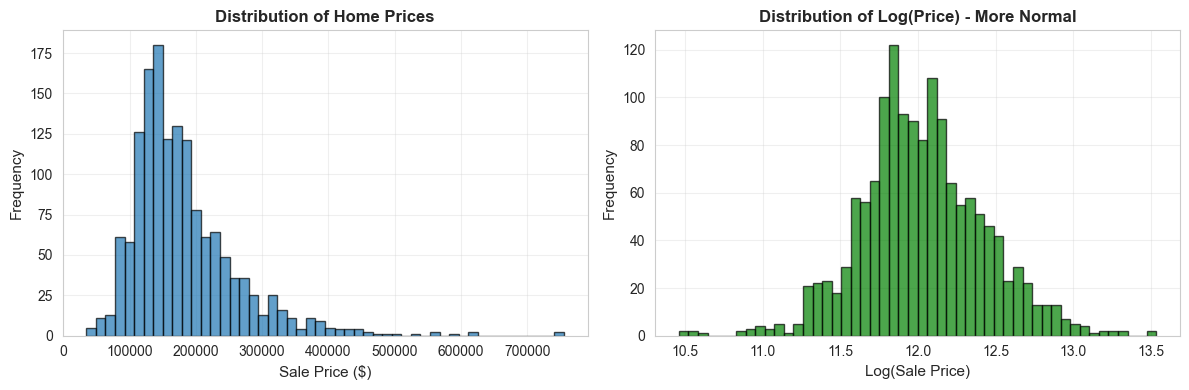


💡 Note: We'll use log(price) as our target for better model performance.


In [26]:
# Prepare the data for modeling
# Select target variable
y = housing_df['SalePrice'].copy()

# Select numeric features (to simplify for this lab)
numeric_features = housing_df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features.remove('SalePrice')  # Remove target

# Also select some important categorical features and encode them
categorical_features = ['MSZoning', 'Street', 'LotShape', 'LandContour', 'LotConfig',
                       'Neighborhood', 'BldgType', 'HouseStyle', 'RoofStyle', 
                       'ExterQual', 'ExterCond', 'Foundation', 'HeatingQC',
                       'CentralAir', 'KitchenQual', 'PavedDrive', 'SaleCondition']

# Create feature matrix
X_numeric = housing_df[numeric_features].copy()
X_categorical = housing_df[categorical_features].copy()

# One-hot encode categorical variables
X_categorical_encoded = pd.get_dummies(X_categorical, drop_first=True)

# Combine numeric and encoded categorical
X = pd.concat([X_numeric, X_categorical_encoded], axis=1)

# Handle any remaining missing values (simple imputation with median)
X = X.fillna(X.median())

print(f"\n✅ Prepared feature matrix:")
print(f"   Shape: {X.shape}")
print(f"   Features: {X.shape[1]}")
print(f"   Samples: {X.shape[0]}")

print(f"\n📊 Sample features:")
print(f"   Numeric: {numeric_features[:5]}...")
print(f"   Categorical (encoded): {list(X_categorical_encoded.columns[:5])}...")

# Show distribution of target
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(y, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Sale Price ($)', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Distribution of Home Prices', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(np.log(y), bins=50, edgecolor='black', alpha=0.7, color='green')
plt.xlabel('Log(Sale Price)', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Distribution of Log(Price) - More Normal', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n💡 Note: We'll use log(price) as our target for better model performance.")
y = np.log(y)

In [27]:
# Load semiconductor dataset
semi = pd.read_csv('https://raw.githubusercontent.com/TaddyLab/MBAcourse/master/examples/semiconductor.csv')

print(f"Semiconductor dataset shape: {semi.shape}")
print(f"\nTarget variable (FAIL) distribution:")
print(semi['FAIL'].value_counts())
semi.head()

Semiconductor dataset shape: (1477, 201)

Target variable (FAIL) distribution:
FAIL
0    1377
1     100
Name: count, dtype: int64


,FAIL,SIG1,SIG2,SIG3,SIG4,SIG5,SIG6,SIG7,SIG8,SIG9,...,SIG191,SIG192,SIG193,SIG194,SIG195,SIG196,SIG197,SIG198,SIG199,SIG200
0,0,2.223779,-0.349018,-1.985797,-2.600993,0.451092,0.856625,0.019999,5.552095,-1.217598,...,-0.493650,-0.081946,-0.026963,0.069390,0.000884,-0.090158,0.567668,0.136708,0.258290,-0.110619
1,1,-0.130378,-0.381318,-1.285172,-0.766302,-3.098302,1.257852,0.792258,3.052683,-0.596629,...,-0.242341,-0.040653,-0.248808,-0.206819,-0.113580,0.087156,-0.075984,0.359806,0.352307,-0.065168
2,0,-0.871138,-0.825300,-1.615008,-0.448803,-2.570782,-1.345798,3.561107,2.748009,-0.898133,...,-0.210873,-0.224043,-0.668168,-0.067575,-0.557790,0.050106,0.352167,-0.136979,0.270314,0.231886
3,0,-0.877341,-1.905598,-2.306114,-1.210761,-4.037471,-2.223608,2.404128,0.769476,5.605738,...,-0.244826,0.100125,-0.016613,0.139226,0.153687,-0.222902,-0.324682,0.330688,-0.053124,-0.046525
4,0,-2.113456,-2.313845,-2.917153,-3.333467,-4.439346,3.029632,-0.177130,0.268809,2.673137,...,0.523039,-0.104421,0.110383,0.099062,0.347613,-0.213793,0.090675,0.081936,-0.129969,-0.435595


## Part 1: Ridge Regression

### What is Ridge Regression?

**Key Concept:** Ridge regression shrinks coefficients toward zero BUT never eliminates them completely.

**When to use Ridge:**
- You believe most variables are relevant
- You have multicollinearity (correlated predictors)
- You want stable, interpretable coefficients

**The Math (simplified):**
- Regular regression: Minimize prediction error
- Ridge: Minimize prediction error + λ × (sum of squared coefficients)

**λ (lambda)** is the penalty parameter:
- λ = 0: Regular regression (no penalty)
- λ = large: Heavy penalty (coefficients shrink toward zero)

---

### Standardize Features

**Important:** Always standardize features before regularization!

**Why?** Regularization penalizes coefficient magnitude. If variables are on different scales (e.g., square footage in thousands vs. number of bedrooms), the penalty would be unfair.

**Example:** Without standardization, a \$1,000 change in coefficient for 'LotArea' (measured in sq ft) would be penalized differently than a \$1,000 coefficient for 'Bedrooms' (measured in count).

In [28]:
# Standardize features (mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier interpretation
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Before standardization:")
print(X.describe().loc[['mean', 'std']].round(2))
print("\nAfter standardization:")
print(X_scaled_df.describe().loc[['mean', 'std']].round(2))

Before standardization:
          Id  MSSubClass  LotFrontage   LotArea  OverallQual  OverallCond  \
mean  730.50        56.9        69.86  10516.83         6.10         5.58   
std   421.61        42.3        22.03   9981.26         1.38         1.11   

      YearBuilt  YearRemodAdd  MasVnrArea  BsmtFinSF1  ...  GarageArea  \
mean    1971.27       1984.87      103.12      443.64  ...      472.98   
std       30.20         20.65      180.73      456.10  ...      213.80   

      WoodDeckSF  OpenPorchSF  EnclosedPorch  3SsnPorch  ScreenPorch  \
mean       94.24        46.66          21.95       3.41        15.06   
std       125.34        66.26          61.12      29.32        55.76   

      PoolArea  MiscVal  MoSold   YrSold  
mean      2.76    43.49    6.32  2007.82  
std      40.18   496.12    2.70     1.33  

[2 rows x 37 columns]

After standardization:
       Id  MSSubClass  LotFrontage  LotArea  OverallQual  OverallCond  \
mean  0.0        -0.0          0.0     -0.0          0.

### Fit Ridge Regression with Cross-Validation

We'll use **cross-validation** to automatically find the best alpha value.

In [29]:
# Define range of alpha values 
alphas = np.logspace(-3, 4, 200)  # 0.001 to ~3162, with more detail around 1000

# Fit Ridge with cross-validation
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_scaled, y)

print(f"Best alpha: {ridge_cv.alpha_:.2f}")
print(f"R² Score: {ridge_cv.score(X_scaled, y):.4f}")

Best alpha: 174.26
R² Score: 0.9015


### Visualize: How Does Error Change with λ?

This plot shows model performance across different penalty values.

In [30]:
from sklearn.model_selection import cross_val_score

# Calculate CV MSE for different alpha values (THIS IS WHAT RIDGECV USES)
cv_mse_scores = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    # Use cross-validation to get out-of-sample error
    cv_scores = cross_val_score(ridge, X_scaled, y, cv=5, 
                                 scoring='neg_mean_squared_error')
    cv_mse = -cv_scores.mean()  # Convert to positive MSE
    cv_mse_scores.append(cv_mse)

# Create interactive Plotly plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=alphas,
    y=cv_mse_scores,
    mode='lines',
    name='CV MSE',
    line=dict(color='steelblue', width=3),
    hovertemplate='Alpha: %{x:.4f}<br>CV MSE: %{y:.6f}<extra></extra>'
))

fig.add_vline(
    x=ridge_cv.alpha_,
    line_dash='dash',
    line_color='red',
    annotation_text=f'Best α = {ridge_cv.alpha_:.2f}',
    annotation_position='top'
)

fig.update_xaxes(type='log', title='Alpha - Penalty Parameter')
fig.update_yaxes(title='Cross-Validation MSE (Out-of-Sample)')
fig.update_layout(
    title='Ridge Regression: CV Error vs. Penalty Strength',
    hovermode='x unified',
    height=500,
    template='plotly_white'
)

fig.show()

print("\n📊 Interpretation:")
print("• This shows OUT-OF-SAMPLE error (what RidgeCV actually optimizes)")
print("• Red line now shows the minimum of the curve!")
print("• Too low alpha = overfitting (high CV error)")
print("• Too high alpha = underfitting (high CV error)")


📊 Interpretation:
• This shows OUT-OF-SAMPLE error (what RidgeCV actually optimizes)
• Red line now shows the minimum of the curve!
• Too low alpha = overfitting (high CV error)
• Too high alpha = underfitting (high CV error)


### Examine Coefficients

Compare coefficients at different penalty strengths.

In [31]:
# Get coefficients for different alphas
ridge_low = Ridge(alpha=0.1)
ridge_low.fit(X_scaled, y)

ridge_best = Ridge(alpha=ridge_cv.alpha_)
ridge_best.fit(X_scaled, y)

ridge_high = Ridge(alpha=100)
ridge_high.fit(X_scaled, y)

# Create comparison DataFrame - show top features by magnitude
coef_comparison = pd.DataFrame({
    'Feature': X.columns,
    'Low Penalty (α=0.1)': ridge_low.coef_,
    f'Best (α={ridge_cv.alpha_:.1f})': ridge_best.coef_,
    'High Penalty (α=100)': ridge_high.coef_
}).round(4)

# Add absolute value for sorting
coef_comparison['Abs_Best'] = coef_comparison[f'Best (α={ridge_cv.alpha_:.1f})'].abs()
coef_comparison = coef_comparison.sort_values('Abs_Best', ascending=False)

print("\n Ridge Coefficients at Different Penalty Levels (Top 15 Features):")
print(coef_comparison.head(15).drop('Abs_Best', axis=1).to_string(index=False))

print("\n💡 Key Insight:")
print("As penalty increases, coefficients shrink but NEVER reach exactly zero.")
print(f"All {len(X.columns)} variables stay in the model.")



 Ridge Coefficients at Different Penalty Levels (Top 15 Features):
              Feature  Low Penalty (α=0.1)  Best (α=174.3)  High Penalty (α=100)
          OverallQual               0.0793          0.0701                0.0746
            GrLivArea               0.0561          0.0418                0.0452
          OverallCond               0.0423          0.0358                0.0384
           GarageCars               0.0500          0.0349                0.0381
            YearBuilt               0.0441          0.0312                0.0349
             1stFlrSF               0.0344          0.0310                0.0320
 Neighborhood_NridgHt               0.0328          0.0293                0.0310
             FullBath               0.0252          0.0263                0.0268
         TotRmsAbvGrd               0.0205          0.0241                0.0233
         BsmtFullBath               0.0257          0.0228                0.0240
             2ndFlrSF               0.036

### Visualize Coefficient Shrinkage

Watch how coefficients change as we increase the penalty.

In [32]:
# Calculate coefficient paths
coef_paths = []
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_scaled, y)
    coef_paths.append(ridge.coef_)

coef_paths = np.array(coef_paths)

# Create interactive Plotly plot
fig = go.Figure()

# Add a line for each feature
for i, feature in enumerate(X.columns):
    fig.add_trace(go.Scatter(
        x=alphas,
        y=coef_paths[:, i],
        mode='lines',
        name=feature,
        line=dict(width=2),
        hovertemplate=f'{feature}<br>Alpha: %{{x:.4f}}<br>Coefficient: %{{y:.4f}}<extra></extra>'
    ))

# Add vertical line for best alpha
fig.add_vline(
    x=ridge_cv.alpha_,
    line_dash='dash',
    line_color='red',
    annotation_text=f'Best α = {ridge_cv.alpha_:.2f}',
    annotation_position='top left'  # Changed from 'top right'
)

fig.update_xaxes(type='log', title='Alpha (α) - Penalty Parameter')
fig.update_yaxes(title='Coefficient Value')
fig.update_layout(
    title='Ridge: Coefficient Shrinkage Path<br><sub>Click legend to show/hide features. Double-click to isolate.</sub>',
    hovermode='closest',
    height=600,
    width=1200,  # Make it wider to accommodate legend
    template='plotly_white',
    showlegend=True,
    legend=dict(
        yanchor="top",
        y=1,
        xanchor="left",
        x=1.02,  # Move legend slightly more to the right
        bgcolor='rgba(255,255,255,0.8)',  # Semi-transparent background
        bordercolor='gray',
        borderwidth=1
    ),
    margin=dict(r=200)  # Add right margin for legend
)

fig.show()

print("\n📊 What you're seeing:")
print("• Coefficients shrink toward (but never reach) zero as α increases")
print("• At α = 1000, most coefficients are very small (near zero)")
print("• Beyond optimal α, the model is over-regularized")
print("\n💡 The 'bunching' near zero is normal - that's Ridge working!")


📊 What you're seeing:
• Coefficients shrink toward (but never reach) zero as α increases
• At α = 1000, most coefficients are very small (near zero)
• Beyond optimal α, the model is over-regularized

💡 The 'bunching' near zero is normal - that's Ridge working!


___
# 🔥 Ridge Lab 🔥

> **W4RN1NG:** Y0U R 4B0UT 2 3NT3R TH3 SHR1NK4G3 Z0N3 ⚡



### 1. Load the semi conductor data and split into testing and training

In [33]:
# 1. Load the semiconductor dataset and split into testing and training sets
np.random.seed(1818)

# Load data
semi = pd.read_csv('https://raw.githubusercontent.com/TaddyLab/MBAcourse/master/examples/semiconductor.csv')

# Split into train and test (90% train, 10% test - matching R's 0.9)
X = semi.drop('FAIL', axis=1)
y = semi['FAIL']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.9, random_state=1818
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Number of features: {X_train.shape[1]}")

# Scale the features (Ridge is sensitive to scale)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training set size: 1329
Test set size: 148
Number of features: 200


### 2. Estimate a ridge model using the training data to predict FAIL as a function of all other variables. Store this model as ridge_mod2


In [43]:
# Define range of alpha values 
alphas = np.logspace(-3, 4, 300)  # 0.001 to ~3162, with more detail around 1000

# Fit Ridge with cross-validation
ridge_mod2 = RidgeCV(alphas=alphas, cv=5)
ridge_mod2.fit(X_train, y_train)

print(f"Best alpha: {ridge_mod2.alpha_:.2f}")
print(f"R² Score: {ridge_mod2.score(X_test, y_test):.4f}")




Best alpha: 5236.77
R² Score: 0.0249


In [44]:
from sklearn.model_selection import cross_val_score

# Calculate CV MSE for different alpha values (THIS IS WHAT RIDGECV USES)
cv_mse_scores = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    # Use cross-validation to get out-of-sample error
    cv_scores = cross_val_score(ridge, X_train, y_train, cv=5, 
                                 scoring='neg_mean_squared_error')
    cv_mse = -cv_scores.mean()  # Convert to positive MSE
    cv_mse_scores.append(cv_mse)

# Create interactive Plotly plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=alphas,
    y=cv_mse_scores,
    mode='lines',
    name='CV MSE',
    line=dict(color='steelblue', width=3),
    hovertemplate='Alpha: %{x:.4f}<br>CV MSE: %{y:.6f}<extra></extra>'
))

fig.add_vline(
    x=ridge_cv.alpha_,
    line_dash='dash',
    line_color='red',
    annotation_text=f'Best α = {ridge_cv.alpha_:.2f}',
    annotation_position='top'
)

fig.update_xaxes(type='log', title='Alpha - Penalty Parameter')
fig.update_yaxes(title='Cross-Validation MSE (Out-of-Sample)')
fig.update_layout(
    title='Ridge Regression: CV Error vs. Penalty Strength',
    hovermode='x unified',
    height=500,
    template='plotly_white'
)

fig.show()

print("\n📊 Interpretation:")
print("• This shows OUT-OF-SAMPLE error (what RidgeCV actually optimizes)")
print("• Red line now shows the minimum of the curve!")
print("• Too low alpha = overfitting (high CV error)")
print("• Too high alpha = underfitting (high CV error)")


📊 Interpretation:
• This shows OUT-OF-SAMPLE error (what RidgeCV actually optimizes)
• Red line now shows the minimum of the curve!
• Too low alpha = overfitting (high CV error)
• Too high alpha = underfitting (high CV error)


In [45]:
# Calculate coefficient paths
coef_paths = []
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    coef_paths.append(ridge.coef_)

coef_paths = np.array(coef_paths)

# Create interactive Plotly plot
fig = go.Figure()

# Add a line for each feature
for i, feature in enumerate(X.columns):
    fig.add_trace(go.Scatter(
        x=alphas,
        y=coef_paths[:, i],
        mode='lines',
        name=feature,
        line=dict(width=2),
        hovertemplate=f'{feature}<br>Alpha: %{{x:.4f}}<br>Coefficient: %{{y:.4f}}<extra></extra>'
    ))

# Add vertical line for best alpha
fig.add_vline(
    x=ridge_cv.alpha_,
    line_dash='dash',
    line_color='red',
    annotation_text=f'Best α = {ridge_cv.alpha_:.2f}',
    annotation_position='top left'  # Changed from 'top right'
)

fig.update_xaxes(type='log', title='Alpha (α) - Penalty Parameter')
fig.update_yaxes(title='Coefficient Value')
fig.update_layout(
    title='Ridge: Coefficient Shrinkage Path<br><sub>Click legend to show/hide features. Double-click to isolate.</sub>',
    hovermode='closest',
    height=600,
    width=1200,  # Make it wider to accommodate legend
    template='plotly_white',
    showlegend=True,
    legend=dict(
        yanchor="top",
        y=1,
        xanchor="left",
        x=1.02,  # Move legend slightly more to the right
        bgcolor='rgba(255,255,255,0.8)',  # Semi-transparent background
        bordercolor='gray',
        borderwidth=1
    ),
    margin=dict(r=200)  # Add right margin for legend
)

fig.show()

print("\n📊 What you're seeing:")
print("• Coefficients shrink toward (but never reach) zero as α increases")
print("• At α = 1000, most coefficients are very small (near zero)")
print("• Beyond optimal α, the model is over-regularized")
print("\n💡 The 'bunching' near zero is normal - that's Ridge working!")


📊 What you're seeing:
• Coefficients shrink toward (but never reach) zero as α increases
• At α = 1000, most coefficients are very small (near zero)
• Beyond optimal α, the model is over-regularized

💡 The 'bunching' near zero is normal - that's Ridge working!


### 3. Run the code below to see the shrinkage path of the model. Describe the shrinkage path of the model in your own words. What is going on with the model?


In [46]:

# Calculate CV scores for plotting
cv_mse_scores = []
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    cv_scores = cross_val_score(ridge, X_train_scaled, y_train, 
                                cv=5, scoring='neg_mean_squared_error')
    cv_mse_scores.append(-cv_scores.mean())

cv_mse_scores = np.array(cv_mse_scores)

# Plot 1: CV Error vs Alpha
fig1 = go.Figure()

fig1.add_trace(go.Scatter(
    x=alphas,
    y=cv_mse_scores,
    mode='lines',
    name='CV MSE',
    line=dict(color='steelblue', width=3),
    hovertemplate='α: %{x:.4f}<br>CV MSE: %{y:.6f}<extra></extra>'
))

fig1.add_vline(
    x=ridge_mod2.alpha_,
    line_dash='dash',
    line_color='red',
    annotation_text=f'Best α = {ridge_mod2.alpha_:.2f}',
    annotation_position='top left'
)

fig1.update_xaxes(type='log', title='Alpha  - Penalty Parameter')
fig1.update_yaxes(title='Cross-Validation MSE')
fig1.update_layout(
    title='Ridge Regression: Cross-Validation Error',
    hovermode='x unified',
    height=500,
    template='plotly_white'
)

fig1.show()

### 4. Run the code below to see the coefficients. Describe the coefficients under different alpha values. What is going on? 

In [ ]:

# Choose interesting alpha values to compare
alpha_values = [
    0.01,           # Low regularization
    1.0,            # Medium regularization
    ridge_mod2.alpha_,  # Optimal alpha
    100.0,          # High regularization
    1000.0,          # Very high regularization
    10000.0          # EXTREME regularization
]

# Create a comparison dataframe
comparison_data = {'Feature': ['(Intercept)'] + list(X.columns)}

for alpha_val in alpha_values:
    ridge = Ridge(alpha=alpha_val)
    ridge.fit(X_train_scaled, y_train)
    
    coefs = [ridge.intercept_] + list(ridge.coef_)
    
    # Mark the optimal alpha
    if alpha_val == ridge_mod2.alpha_:
        comparison_data[f'α = {alpha_val:.2f} ⭐'] = coefs
    else:
        comparison_data[f'α = {alpha_val:.2f}'] = coefs

comparison_df = pd.DataFrame(comparison_data)

print("\n Shrinkage comparison:")
print("-" * 70)
print(comparison_df.to_string(index=False))



---

## Part 2: Lasso Regression

### What is Lasso Regression?

**Key Concept:** Lasso can eliminate variables by setting coefficients to EXACTLY zero.

**When to use Lasso:**
- You have many variables and want automatic feature selection
- You suspect many variables are irrelevant
- You want a simpler, more interpretable model
- You need to explain which variables matter most

**The Math (simplified):**
- Ridge: Minimize error + alpha × (sum of squared coefficients)
- Lasso: Minimize error + alpha × (sum of absolute coefficients)

**The difference:** Using absolute values instead of squares enables Lasso to eliminate variables.

---

### Fit Lasso Regression with Cross-Validation

In [ ]:
y = housing_df['SalePrice'].copy()

# Select numeric features (to simplify for this lab)
numeric_features = housing_df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features.remove('SalePrice')  # Remove target

# Also select some important categorical features and encode them
categorical_features = ['MSZoning', 'Street', 'LotShape', 'LandContour', 'LotConfig',
                       'Neighborhood', 'BldgType', 'HouseStyle', 'RoofStyle', 
                       'ExterQual', 'ExterCond', 'Foundation', 'HeatingQC',
                       'CentralAir', 'KitchenQual', 'PavedDrive', 'SaleCondition']

# Create feature matrix
X_numeric = housing_df[numeric_features].copy()
X_categorical = housing_df[categorical_features].copy()

# One-hot encode categorical variables
X_categorical_encoded = pd.get_dummies(X_categorical, drop_first=True)

# Combine numeric and encoded categorical
X = pd.concat([X_numeric, X_categorical_encoded], axis=1)

# Handle any remaining missing values (simple imputation with median)
X = X.fillna(X.median())

# Scale the FULL dataset
X_full_scaled = scaler.fit_transform(X)  # Scale all of X

# Fit Lasso with cross-validation
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_cv.fit(X_full_scaled, y)  # Now lengths match!

print(f"Best alpha (λ): {lasso_cv.alpha_:.4f}")
print(f"R² Score: {lasso_cv.score(X_full_scaled, y):.4f}")

# Count non-zero coefficients
n_nonzero = np.sum(lasso_cv.coef_ != 0)
print(f"\nNumber of non-zero coefficients: {n_nonzero} out of {len(lasso_cv.coef_)}")

### Visualize: Lasso Error vs. Penalty

In [ ]:
# Use fewer alpha values for faster plotting
alphas_plot = np.logspace(-3, 6, 30)  # Reduced from 100 to 30

# Calculate CV scores for plotting
cv_mse_scores_lasso = []

for alpha in alphas_plot:
    lasso = Lasso(alpha=alpha, max_iter=10000, random_state=42)
    cv_scores = cross_val_score(lasso, X_full_scaled, y, 
                                cv=5, scoring='neg_mean_squared_error')
    cv_mse_scores_lasso.append(-cv_scores.mean())

cv_mse_scores_lasso = np.array(cv_mse_scores_lasso)

# Create plot
fig1 = go.Figure()

fig1.add_trace(go.Scatter(
    x=alphas_plot,
    y=cv_mse_scores_lasso,
    mode='lines+markers',  # Add markers to show the points
    name='CV MSE',
    line=dict(color='green', width=3),
    marker=dict(size=6),
    hovertemplate='Alpha: %{x:.4f}<br>CV MSE: %{y:.2f}<extra></extra>'
))

fig1.add_vline(
    x=lasso_cv.alpha_,
    line_dash='dash',
    line_color='red',
    annotation_text=f'Best α = {lasso_cv.alpha_:.4f}',
    annotation_position='top'
)

fig1.update_xaxes(type='log', title='Alpha (λ) - Penalty Parameter')
fig1.update_yaxes(title='Cross-Validation MSE (Out-of-Sample)')
fig1.update_layout(
    title='Lasso Regression: CV Error vs. Penalty Strength (Housing Data)<br><sub>Red line shows minimum out-of-sample error</sub>',
    hovermode='x unified',
    height=500,
    template='plotly_white'
)

fig1.show()

### Compare Lasso Coefficients at Different Penalties

In [ ]:
# Get coefficients for different alphas
lasso_low = Lasso(alpha=0.001, max_iter=10000)
lasso_low.fit(X_full_scaled, y)  # Changed from X_scaled

lasso_best = Lasso(alpha=lasso_cv.alpha_, max_iter=10000)
lasso_best.fit(X_full_scaled, y)  # Changed from X_scaled

lasso_high = Lasso(alpha=1000, max_iter=10000)
lasso_high.fit(X_full_scaled, y)  # Changed from X_scaled

# Create comparison DataFrame
coef_comparison_lasso = pd.DataFrame({
    'Feature': X.columns,
    'Low Penalty (α=0.001)': lasso_low.coef_,
    f'Best (α={lasso_cv.alpha_:.4f})': lasso_best.coef_,
    'High Penalty (α=0.01)': lasso_high.coef_
}).round(4)

# Add absolute value for sorting
coef_comparison_lasso['Abs_Best'] = coef_comparison_lasso[f'Best (α={lasso_cv.alpha_:.4f})'].abs()
coef_comparison_lasso = coef_comparison_lasso.sort_values('Abs_Best', ascending=False)

print("\n📊 Lasso Coefficients at Different Penalty Levels (Top 20 Features):")
print(coef_comparison_lasso.head(20).drop('Abs_Best', axis=1).to_string(index=False))

print("\n💡 Key Insight:")
print("Notice how some coefficients become EXACTLY 0.0000")
print("Lasso automatically performs feature selection!")

# Highlight which features are selected
n_selected_low = np.sum(lasso_low.coef_ != 0)
n_selected_best = np.sum(lasso_best.coef_ != 0)
n_selected_high = np.sum(lasso_high.coef_ != 0)
n_total = len(X.columns)

print(f"\n✅ Features Selected:")
print(f"   Low Penalty (α=0.001): {n_selected_low}/{n_total} features")
print(f"   Best (α={lasso_cv.alpha_:.4f}): {n_selected_best}/{n_total} features")
print(f"   High Penalty (α=1000): {n_selected_high}/{n_total} features")

print(f"\n🏠 Business Impact: Lasso tells us we only need {n_selected_best} out of {n_total} features!")
print(f"   That's a {(1-n_selected_best/n_total)*100:.1f}% reduction in complexity!")

### Visualize Lasso Coefficient Paths

In [ ]:
# Create fewer alphas with extended range
alphas_plot = np.logspace(-3, 3, 20)  # 20 alphas from 0.001 to 1000

# Calculate coefficient paths for Lasso
coef_paths_lasso = []
n_nonzero_path = []  # Track number of non-zero coefficients

for alpha in alphas_plot:
    lasso = Lasso(alpha=alpha, max_iter=10000, random_state=42)
    lasso.fit(X_full_scaled, y)
    coef_paths_lasso.append(lasso.coef_)
    n_nonzero_path.append(np.sum(lasso.coef_ != 0))

coef_paths_lasso = np.array(coef_paths_lasso)

# Create interactive Plotly plot
fig = go.Figure()

# Add a line for each feature
for i, feature in enumerate(X.columns):
    fig.add_trace(go.Scatter(
        x=alphas_plot,
        y=coef_paths_lasso[:, i],
        mode='lines',
        name=feature,
        line=dict(width=2),
        hovertemplate=f'{feature}<br>Alpha: %{{x:.4f}}<br>Coefficient: %{{y:.4f}}<extra></extra>'
    ))

# Add vertical line for best alpha
fig.add_vline(
    x=lasso_cv.alpha_,
    line_dash='dash',
    line_color='red',
    annotation_text=f'Best α = {lasso_cv.alpha_:.4f}',
    annotation_position='top right'
)

fig.update_xaxes(type='log', title='Alpha (λ) - Penalty Parameter')
fig.update_yaxes(title='Coefficient Value')
fig.update_layout(
    title='Lasso: Coefficient Shrinkage Path (Feature Selection)<br><sub>Watch coefficients hit zero! Click legend to explore.</sub>',
    hovermode='closest',
    height=600,
    width=1200,
    template='plotly_white',
    showlegend=True,
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=1.01
    ),
    margin=dict(r=200)  # Add margin for legend
)

fig.show()

print("\n📊 Interpretation:")
print("• Coefficients hit zero and stay there (unlike Ridge)")
print("• The order in which features are eliminated tells us their importance")
print("• Features that survive longest are most important")
print("\n💡 Interactive Tips:")
print("  • Isolate a feature to see exactly when it gets eliminated")
print("  • Notice how some features go to zero quickly, others persist")

# Bonus: Show feature elimination order
print("\n🔥 Feature Elimination Timeline:")
print("-" * 70)
print(f"At α = {alphas_plot[0]:.4f} (low): {n_nonzero_path[0]} features active")
print(f"At α = {lasso_cv.alpha_:.4f} (optimal): {np.sum(lasso_cv.coef_ != 0)} features active")
print(f"At α = {alphas_plot[-1]:.4f} (high): {n_nonzero_path[-1]} features active")

___
# Lasso Lab

### 1. Load the semiconductor dataset and split into testing and training sets


In [ ]:
# Split into train and test (90% train, 10% test)
X = semi.drop('FAIL', axis=1)
y = semi['FAIL']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.9, random_state=1818
)

print(f"✅ Data Loaded Successfully!")
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Number of features: {X_train.shape[1]}")

# Scale the features (Lasso is sensitive to scale)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 2. Estimate a Lasso model using the training data to predict FAIL as a function of all other variables. Store this model as lasso_mod2

In [ ]:
# your code here


# Create a range of alpha values to test
alphas = np.logspace(-3, 1, 100)

# Use LassoCV to find the best alpha via cross-validation
lasso_mod2 = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_mod2.fit(X_train_scaled, y_train)

print(f"\n✅ Best alpha (α): {lasso_mod2.alpha_:.4f}")
n_nonzero = np.sum(lasso_mod2.coef_ != 0)
print(f"✅ Number of non-zero coefficients: {n_nonzero} out of {len(lasso_mod2.coef_)}")
print(f"\n💡 Lasso selected {n_nonzero} features out of {len(lasso_mod2.coef_)} total!")
print(f"   That's {(n_nonzero/len(lasso_mod2.coef_))*100:.1f}% of features!")

### 3. Plot the cross-validation error curve

In [ ]:

# Calculate CV scores for plotting
cv_mse_scores_lasso = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    cv_scores = cross_val_score(lasso, X_train_scaled, y_train, 
                                cv=5, scoring='neg_mean_squared_error')
    cv_mse_scores_lasso.append(-cv_scores.mean())

cv_mse_scores_lasso = np.array(cv_mse_scores_lasso)

# Create plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=alphas,
    y=cv_mse_scores_lasso,
    mode='lines',
    name='CV MSE',
    line=dict(color='green', width=3),
    hovertemplate='Alpha: %{x:.4f}<br>CV MSE: %{y:.4f}<extra></extra>'
))

fig.add_vline(
    x=lasso_mod2.alpha_,
    line_dash='dash',
    line_color='red',
    annotation_text=f'Best α = {lasso_mod2.alpha_:.4f}',
    annotation_position='top'
)

fig.update_xaxes(type='log', title='Alpha (α) - Penalty Parameter')
fig.update_yaxes(title='Cross-Validation MSE (Out-of-Sample)')
fig.update_layout(
    title='Lasso Regression: CV Error vs. Penalty Strength<br><sub>Red line shows minimum out-of-sample error</sub>',
    hovermode='x unified',
    height=500,
    template='plotly_white'
)

fig.show()


---

## Part 3: Ridge vs. Lasso Comparison

In [ ]:
# ================================================================
# Prepare Housing Data - Train/Test Split
# ================================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, RidgeCV, LassoCV

# Set seed
np.random.seed(1818)

# Prepare target
y = housing_df['SalePrice'].copy()

# Select numeric features
numeric_features = housing_df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features.remove('SalePrice')

# Select categorical features
categorical_features = ['MSZoning', 'Street', 'LotShape', 'LandContour', 'LotConfig',
                       'Neighborhood', 'BldgType', 'HouseStyle', 'RoofStyle', 
                       'ExterQual', 'ExterCond', 'Foundation', 'HeatingQC',
                       'CentralAir', 'KitchenQual', 'PavedDrive', 'SaleCondition']

# Create feature matrix
X_numeric = housing_df[numeric_features].copy()
X_categorical = housing_df[categorical_features].copy()

# One-hot encode categorical variables
X_categorical_encoded = pd.get_dummies(X_categorical, drop_first=True)

# Combine numeric and encoded categorical
X = pd.concat([X_numeric, X_categorical_encoded], axis=1)

# Handle missing values
X = X.fillna(X.median())

print(f"Total features: {X.shape[1]}")
print(f"Total samples: {X.shape[0]}")

# Split into train and test (90% train, 10% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.9, random_state=1818
)

print(f"\nTraining set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ================================================================
# Train Ridge Model with Cross-Validation
# ================================================================

print("\n" + "="*70)
print("🔵 TRAINING RIDGE MODEL")
print("="*70)

alphas = np.logspace(-3, 6, 100)

ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train_scaled, y_train)

print(f"✅ Best Ridge alpha: {ridge_cv.alpha_:.4f}")
print(f"✅ Ridge R² (train): {ridge_cv.score(X_train_scaled, y_train):.4f}")
print(f"✅ Ridge R² (test): {ridge_cv.score(X_test_scaled, y_test):.4f}")

# Get the best Ridge model
ridge_best = ridge_cv

# ================================================================
# Train Lasso Model with Cross-Validation
# ================================================================

print("\n" + "="*70)
print("🟢 TRAINING LASSO MODEL")
print("="*70)

lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)

n_nonzero = np.sum(lasso_cv.coef_ != 0)

print(f"✅ Best Lasso alpha: {lasso_cv.alpha_:.4f}")
print(f"✅ Lasso R² (train): {lasso_cv.score(X_train_scaled, y_train):.4f}")
print(f"✅ Lasso R² (test): {lasso_cv.score(X_test_scaled, y_test):.4f}")
print(f"✅ Features selected: {n_nonzero}/{len(lasso_cv.coef_)} ({n_nonzero/len(lasso_cv.coef_)*100:.1f}%)")

# Get the best Lasso model
lasso_best = lasso_cv

# ================================================================
# Compare Ridge vs Lasso Coefficients
# ================================================================

print("\n" + "="*70)
print("⚡ RIDGE VS LASSO COMPARISON")
print("="*70)

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Ridge': ridge_best.coef_,
    'Lasso': lasso_best.coef_
}).round(4)

comparison_df['Abs_Lasso'] = comparison_df['Lasso'].abs()
comparison_df = comparison_df.sort_values('Abs_Lasso', ascending=False)
comparison_df['Lasso_Selected'] = comparison_df['Lasso'] != 0

print("\n📊 Ridge vs. Lasso Coefficient Comparison (Top 20 Features):")
print(comparison_df.head(20).drop('Abs_Lasso', axis=1).to_string(index=False))

n_lasso_selected = comparison_df['Lasso_Selected'].sum()
n_total = len(X_train.columns)

print(f"\n✅ Ridge keeps ALL {n_total} features (just shrinks them)")
print(f"✅ Lasso selects only {n_lasso_selected} features ({n_lasso_selected/n_total*100:.1f}%)")

# Show which important features Lasso eliminated
eliminated = comparison_df[~comparison_df['Lasso_Selected']].copy()
eliminated['Abs_Ridge'] = eliminated['Ridge'].abs()
eliminated = eliminated.sort_values('Abs_Ridge', ascending=False)

if len(eliminated) > 0:
    print(f"\n❌ Top 10 features ELIMINATED by Lasso (but kept by Ridge):")
    print(eliminated[['Feature', 'Ridge', 'Lasso']].head(10).to_string(index=False))

print("\n💡 Management Question: Are these eliminated features truly unimportant,")
print("   or is Lasso being too aggressive? Check the performance metrics!")

# ================================================================
# Performance Summary
# ================================================================

from sklearn.metrics import mean_squared_error, r2_score

y_pred_ridge = ridge_best.predict(X_test_scaled)
y_pred_lasso = lasso_best.predict(X_test_scaled)

ridge_mse = mean_squared_error(y_test, y_pred_ridge)
lasso_mse = mean_squared_error(y_test, y_pred_lasso)

ridge_r2 = r2_score(y_test, y_pred_ridge)
lasso_r2 = r2_score(y_test, y_pred_lasso)

print("\n" + "="*70)
print("🏆 FINAL PERFORMANCE ON TEST SET")
print("="*70)
print(f"Ridge - MSE: {ridge_mse:,.2f} | R²: {ridge_r2:.4f} | Features: {n_total}")
print(f"Lasso - MSE: {lasso_mse:,.2f} | R²: {lasso_r2:.4f} | Features: {n_lasso_selected}")

if lasso_mse < ridge_mse:
    print(f"\n🎯 Winner: LASSO (lower MSE by {ridge_mse - lasso_mse:,.2f})")
    print(f"   Bonus: Uses {n_total - n_lasso_selected} fewer features!")
else:
    print(f"\n🎯 Winner: RIDGE (lower MSE by {lasso_mse - ridge_mse:,.2f})")
    print(f"   But Lasso is simpler with {n_total - n_lasso_selected} fewer features!")

In [ ]:
# Visual comparison of coefficients - show top 20 features
top_features = comparison_df.head(20).copy()

# Create interactive subplot
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Ridge Regression - Top 20 Features', 
                    'Lasso Regression - Top 20 Features'),
    horizontal_spacing=0.15
)

# Ridge coefficients
colors_ridge = ['steelblue' if x > 0 else 'coral' for x in top_features['Ridge']]
fig.add_trace(
    go.Bar(
        y=top_features['Feature'],
        x=top_features['Ridge'],
        orientation='h',
        marker=dict(color=colors_ridge),
        name='Ridge',
        hovertemplate='%{y}<br>Coefficient: %{x:.4f}<extra></extra>'
    ),
    row=1, col=1
)

# Lasso coefficients
colors_lasso = ['green' if x != 0 else 'lightgray' for x in top_features['Lasso']]
fig.add_trace(
    go.Bar(
        y=top_features['Feature'],
        x=top_features['Lasso'],
        orientation='h',
        marker=dict(color=colors_lasso),
        name='Lasso',
        hovertemplate='%{y}<br>Coefficient: %{x:.4f}<extra></extra>'
    ),
    row=1, col=2
)

# Update layout
fig.update_xaxes(title_text='Coefficient Value', row=1, col=1)
fig.update_xaxes(title_text='Coefficient Value', row=1, col=2)
fig.update_yaxes(autorange='reversed', row=1, col=1)
fig.update_yaxes(autorange='reversed', row=1, col=2)

fig.update_layout(
    height=700,
    showlegend=False,
    template='plotly_white',
    title_text='Ridge vs Lasso: Top Features Comparison<br><sub>Hover for exact values. Gray bars = eliminated by Lasso</sub>'
)

fig.show()

print("\n💡 Visual Insight:")
print("• Ridge (Left): All bars have some length - all features contribute")
print("• Lasso (Right): Gray bars = eliminated (coefficient = 0)")
print("• Green bars = features Lasso selected as important for pricing")
print("\n🏠 Manager Takeaway: Focus on the green features when explaining home values!")

### Key Takeaway: What Actually Drives Home Prices?

Let's see what Lasso tells us about important price drivers.

In [ ]:
# Extract and display the most important features according to Lasso
lasso_important = comparison_df[comparison_df['Lasso_Selected']].copy()
lasso_important = lasso_important.sort_values('Abs_Lasso', ascending=False)

print("\n🏆 TOP 15 MOST IMPORTANT FEATURES FOR HOME PRICES (According to Lasso):")
print("="*70)
for i, row in enumerate(lasso_important.head(15).itertuples(), 1):
    direction = "↑ Increases" if row.Lasso > 0 else "↓ Decreases"
    print(f"{i:2d}. {row.Feature:30s} {direction:12s} price (coef: {row.Lasso:7.4f})")
print("="*70)

print("\n💼 BUSINESS IMPLICATIONS:")
print("\nFor Real Estate Agents:")
print("  → Focus marketing materials on these top features")
print("  → Prioritize homes with these characteristics")
print("\nFor Home Buyers:")
print("  → These features offer best value for money")
print("  → Verify data accuracy for these specific items")
print("\nFor Appraisers:")
print("  → Pay special attention to these features in valuation")
print(f"  → Can ignore {len(X.columns) - len(lasso_important)} less important features")